In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import RidgeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.neural_network import MLPClassifier
from matplotlib import pyplot as plt
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [2]:
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, ConfusionMatrixDisplay
from IPython.display import display

In [3]:
X_train95 = pd.read_csv('./data/processed/X_train95.csv')
X_test95 = pd.read_csv('./data/processed/X_test95.csv')

X_train50 = pd.read_csv('./data/processed/X_train50.csv')
X_test50 = pd.read_csv('./data/processed/X_test50.csv')

X_train0 = pd.read_csv('./data/processed/X_train0.csv')
X_test0 = pd.read_csv('./data/processed/X_test0.csv')

X_train02 = pd.read_csv('./data/processed/X_train02.csv')
X_test02 = pd.read_csv('./data/processed/X_test02.csv')

Y_train = pd.read_csv('./data/processed/Y_train.csv').values.ravel()
Y_test = pd.read_csv('./data/processed/Y_test.csv').values.ravel()

print(X_train95.shape, X_train0.shape, Y_train.shape, X_test95.shape, X_train0.shape, Y_test.shape)

(2520, 74) (2520, 123) (2520,) (1080, 74) (2520, 123) (1080,)


In [37]:
def grid_search(estimator, param_grid, cv, scoring, X, Y, randomized=False):
    if randomized:
        gs = RandomizedSearchCV(estimator=estimator, param_distributions=param_grid, n_iter=100, cv=cv, scoring=scoring, random_state=42, n_jobs=-1)
    else:
        gs = GridSearchCV(estimator=estimator, param_grid=param_grid, cv=cv, scoring=scoring)
    gs.fit(X, Y)

    print(f'Best params: {gs.best_params_}')
    print(f'F1 score: {gs.best_score_}')

    display(pd.DataFrame(gs.cv_results_)[['mean_test_score', 'params']].sort_values(by='mean_test_score', ascending=False).head(5))

    return gs.best_params_

In [5]:
def train_and_evaluate(classifier, best_params, X_train, Y_train, X_test, Y_test):
    model = classifier(**best_params)
    model.fit(X_train, Y_train)

    preds = model.predict(X_test)

    print(f'Accuracy: {accuracy_score(Y_test, preds)}')
    print(f'F1 score: {f1_score(Y_test, preds)}')
    print(f'Precision: {precision_score(Y_test, preds)}')
    print(f'Recall: {recall_score(Y_test, preds)}')
    ConfusionMatrixDisplay.from_predictions(Y_test, preds)
    plt.show()

# **Ridge Classifier**

In [6]:
rgc_params = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    'class_weight': [None, 'balanced'],
}

### PCA with 95% explainec variance

In [7]:
rgc95_best_params = grid_search(estimator=RidgeClassifier(), param_grid=rgc_params, cv=5, scoring='f1', X=X_train95, Y=Y_train)

Best params: {'alpha': 1000, 'class_weight': 'balanced'}
F1 score: 0.4928831272977224


,mean_test_score,params
13,0.492883,"{'alpha': 1000, 'class_weight': 'balanced'}"
11,0.492808,"{'alpha': 100, 'class_weight': 'balanced'}"
9,0.485541,"{'alpha': 10, 'class_weight': 'balanced'}"
5,0.484783,"{'alpha': 0.1, 'class_weight': 'balanced'}"
1,0.484783,"{'alpha': 0.001, 'class_weight': 'balanced'}"


Accuracy: 0.7666666666666667
F1 score: 0.4793388429752066
Precision: 0.3483483483483483
Recall: 0.7682119205298014


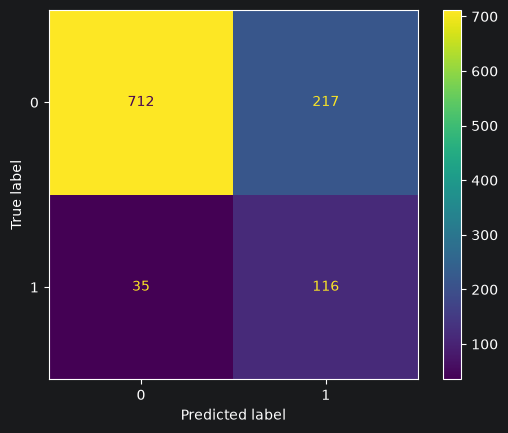

In [8]:
train_and_evaluate(classifier=RidgeClassifier, best_params=rgc95_best_params, X_train=X_train95, Y_train=Y_train, X_test=X_test95, Y_test=Y_test)

### Without PCA

In [9]:
rgc0_best_params = grid_search(estimator=RidgeClassifier(), param_grid=rgc_params, cv=5, scoring='f1', X=X_train0, Y=Y_train)

Best params: {'alpha': 1000, 'class_weight': 'balanced'}
F1 score: 0.4918824937036276


,mean_test_score,params
13,0.491882,"{'alpha': 1000, 'class_weight': 'balanced'}"
11,0.490106,"{'alpha': 100, 'class_weight': 'balanced'}"
9,0.488595,"{'alpha': 10, 'class_weight': 'balanced'}"
5,0.487338,"{'alpha': 0.1, 'class_weight': 'balanced'}"
1,0.487338,"{'alpha': 0.001, 'class_weight': 'balanced'}"


Accuracy: 0.774074074074074
F1 score: 0.48739495798319327
Precision: 0.3569230769230769
Recall: 0.7682119205298014


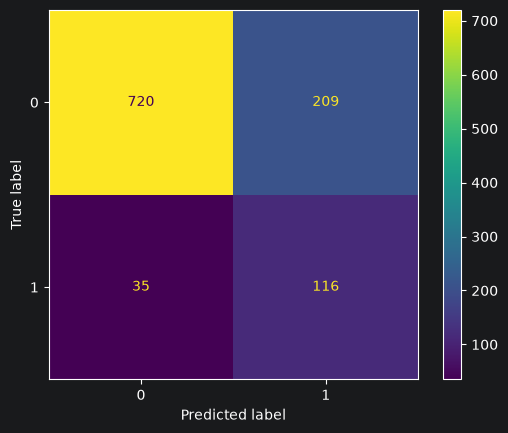

In [10]:
train_and_evaluate(classifier=RidgeClassifier, best_params=rgc0_best_params, X_train=X_train0, Y_train=Y_train, X_test=X_test0, Y_test=Y_test)

### PCA with 50 components

In [11]:
rgc50_best_params = grid_search(estimator=RidgeClassifier(), param_grid=rgc_params, cv=5, scoring='f1', X=X_train50, Y=Y_train)

Best params: {'alpha': 1000, 'class_weight': 'balanced'}
F1 score: 0.46935499805237574


,mean_test_score,params
13,0.469355,"{'alpha': 1000, 'class_weight': 'balanced'}"
11,0.468398,"{'alpha': 100, 'class_weight': 'balanced'}"
9,0.467940,"{'alpha': 10, 'class_weight': 'balanced'}"
5,0.467664,"{'alpha': 0.1, 'class_weight': 'balanced'}"
1,0.467664,"{'alpha': 0.001, 'class_weight': 'balanced'}"


Accuracy: 0.7574074074074074
F1 score: 0.46963562753036436
Precision: 0.33819241982507287
Recall: 0.7682119205298014


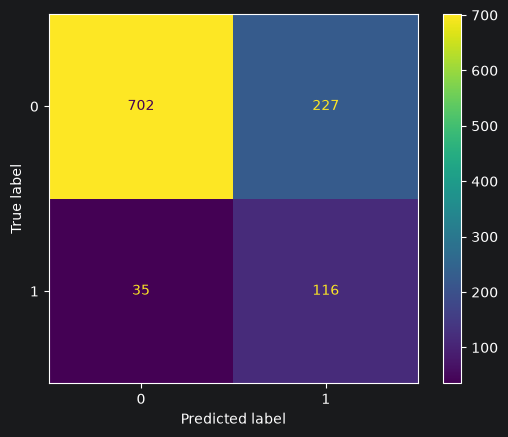

In [12]:
train_and_evaluate(classifier=RidgeClassifier, best_params=rgc50_best_params, X_train=X_train50, Y_train=Y_train, X_test=X_test50, Y_test=Y_test)

# **LDA (Linear Discriminant Analysis)**

In [13]:
lda_params = [
    {
        'solver': ['svd'],
        'shrinkage': [None]
    },
    {
    'solver': ['lsqr', 'eigen'],
    'shrinkage': [None, 'auto', 0.1, 0.3, 0.5, 0.7]
    }
]

### PCA with 95% explained variance

In [14]:
lda95_best_params = grid_search(estimator=LinearDiscriminantAnalysis(), param_grid=lda_params, cv=5, scoring='f1', X=X_train95, Y=Y_train)

Best params: {'shrinkage': 0.7, 'solver': 'lsqr'}
F1 score: 0.4392471990181718


,mean_test_score,params
11,0.439247,"{'shrinkage': 0.7, 'solver': 'lsqr'}"
12,0.439247,"{'shrinkage': 0.7, 'solver': 'eigen'}"
9,0.419835,"{'shrinkage': 0.5, 'solver': 'lsqr'}"
10,0.419835,"{'shrinkage': 0.5, 'solver': 'eigen'}"
7,0.381527,"{'shrinkage': 0.3, 'solver': 'lsqr'}"


Accuracy: 0.8638888888888889
F1 score: 0.5016949152542373
Precision: 0.5138888888888888
Recall: 0.4900662251655629


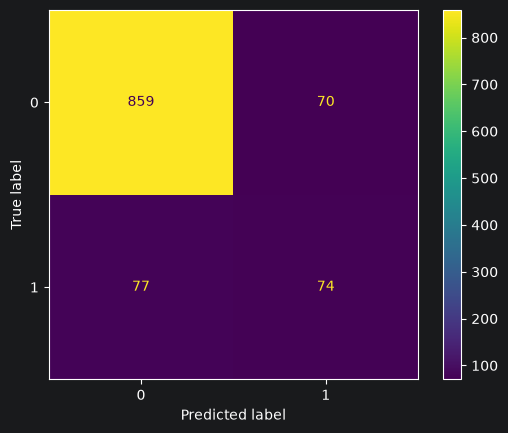

In [15]:
train_and_evaluate(classifier=LinearDiscriminantAnalysis, best_params=lda95_best_params, X_train=X_train95, Y_train=Y_train, X_test=X_test95, Y_test=Y_test)

### Without PCA

In [16]:
import warnings
from sklearn.exceptions import FitFailedWarning

warnings.filterwarnings("ignore", category=FitFailedWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

# this is to get rid of warnings that occur when eigen solver cant fit all instances

In [17]:
lda0_best_params = grid_search(estimator=LinearDiscriminantAnalysis(), param_grid=lda_params, cv=5, scoring='f1', X=X_train0, Y=Y_train)

Best params: {'shrinkage': 0.7, 'solver': 'lsqr'}
F1 score: 0.460866212183603


,mean_test_score,params
12,0.460866,"{'shrinkage': 0.7, 'solver': 'eigen'}"
11,0.460866,"{'shrinkage': 0.7, 'solver': 'lsqr'}"
10,0.441101,"{'shrinkage': 0.5, 'solver': 'eigen'}"
9,0.441101,"{'shrinkage': 0.5, 'solver': 'lsqr'}"
7,0.411912,"{'shrinkage': 0.3, 'solver': 'lsqr'}"


Accuracy: 0.8546296296296296
F1 score: 0.5015873015873016
Precision: 0.4817073170731707
Recall: 0.5231788079470199


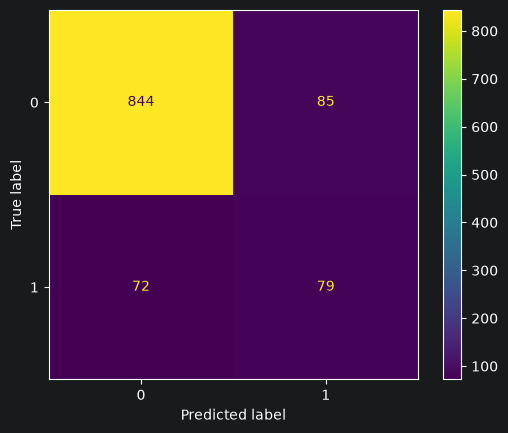

In [18]:
train_and_evaluate(classifier=LinearDiscriminantAnalysis, best_params=lda0_best_params, X_train=X_train0, Y_train=Y_train, X_test=X_test0, Y_test=Y_test)

### PCA with 50 components

In [19]:
lda50_best_params = grid_search(estimator=LinearDiscriminantAnalysis(), param_grid=lda_params, cv=5, scoring='f1', X=X_train50, Y=Y_train)

Best params: {'shrinkage': 0.7, 'solver': 'lsqr'}
F1 score: 0.4124101983412044


,mean_test_score,params
11,0.412410,"{'shrinkage': 0.7, 'solver': 'lsqr'}"
12,0.412410,"{'shrinkage': 0.7, 'solver': 'eigen'}"
9,0.398648,"{'shrinkage': 0.5, 'solver': 'lsqr'}"
10,0.398648,"{'shrinkage': 0.5, 'solver': 'eigen'}"
7,0.378850,"{'shrinkage': 0.3, 'solver': 'lsqr'}"


Accuracy: 0.8629629629629629
F1 score: 0.45985401459854014
Precision: 0.5121951219512195
Recall: 0.41721854304635764


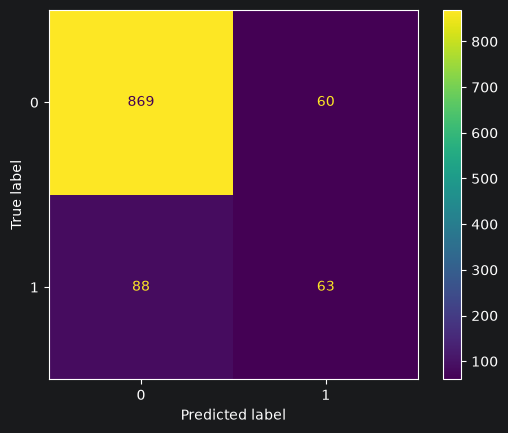

In [20]:
train_and_evaluate(classifier=LinearDiscriminantAnalysis, best_params=lda50_best_params, X_train=X_train50, Y_train=Y_train, X_test=X_test50, Y_test=Y_test)

# Random Forest

In [38]:
from scipy.stats import randint

rf_params = {
    "n_estimators": [1000],
    "class_weight": ['balanced'],
    "max_depth": [None, 10, 15, 20, 30],
    "min_samples_split": randint(2, 50),
    "min_samples_leaf": randint(1, 20),
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True, False],
    "criterion": ["gini", "entropy"]
}

In [39]:
rf02_best_params = grid_search(estimator=RandomForestClassifier(), param_grid=rf_params, cv=5, scoring='f1', X=X_train02, Y=Y_train, randomized=True)

Best params: {'bootstrap': True, 'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 33, 'n_estimators': 1000}
F1 score: 0.4970682384273126


,mean_test_score,params
47,0.497068,"{'bootstrap': True, 'class_weight': 'balanced'..."
26,0.496333,"{'bootstrap': True, 'class_weight': 'balanced'..."
19,0.495909,"{'bootstrap': True, 'class_weight': 'balanced'..."
88,0.494995,"{'bootstrap': False, 'class_weight': 'balanced..."
71,0.494377,"{'bootstrap': False, 'class_weight': 'balanced..."


Accuracy: 0.8166666666666667
F1 score: 0.505
Precision: 0.40562248995983935
Recall: 0.6688741721854304


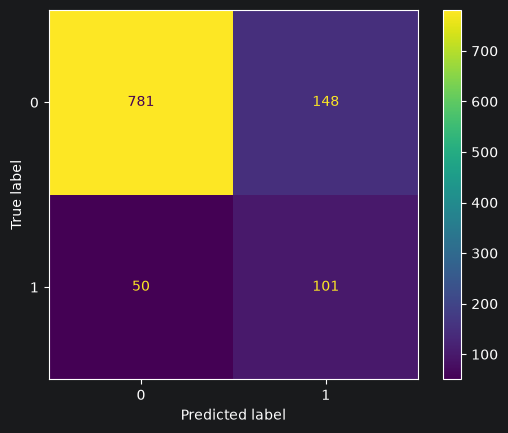

In [40]:
train_and_evaluate(classifier=RandomForestClassifier, best_params=rf02_best_params, X_train=X_train02, Y_train=Y_train, X_test=X_test02, Y_test=Y_test)

# PCA with 95% explained variance

In [41]:
rf95_best_params = grid_search(estimator=RandomForestClassifier(), param_grid=rf_params, cv=5, scoring='f1', X=X_train95, Y=Y_train, randomized=True)

Best params: {'bootstrap': True, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 14, 'min_samples_split': 6, 'n_estimators': 1000}
F1 score: 0.4744715455939634


,mean_test_score,params
82,0.474472,"{'bootstrap': True, 'class_weight': 'balanced'..."
53,0.474265,"{'bootstrap': True, 'class_weight': 'balanced'..."
1,0.471809,"{'bootstrap': True, 'class_weight': 'balanced'..."
5,0.471764,"{'bootstrap': True, 'class_weight': 'balanced'..."
75,0.470315,"{'bootstrap': True, 'class_weight': 'balanced'..."


Accuracy: 0.8138888888888889
F1 score: 0.4859335038363171
Precision: 0.3958333333333333
Recall: 0.6291390728476821


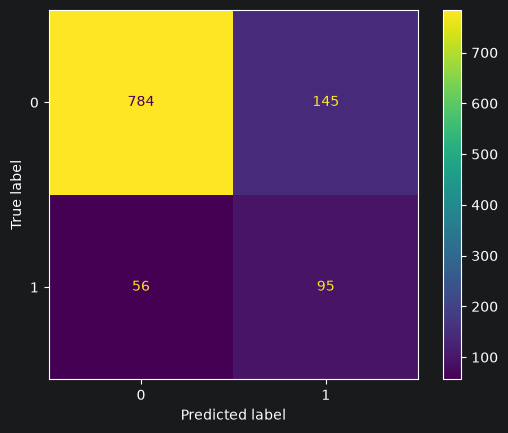

In [42]:
train_and_evaluate(classifier=RandomForestClassifier, best_params=rf95_best_params, X_train=X_train95, Y_train=Y_train, X_test=X_test95, Y_test=Y_test)

### Without PCA

In [43]:
rf0_best_params = grid_search(estimator=RandomForestClassifier(), param_grid=rf_params, cv=5, scoring='f1', X=X_train0, Y=Y_train, randomized=True)

Best params: {'bootstrap': True, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 7, 'min_samples_split': 19, 'n_estimators': 1000}
F1 score: 0.5000965344932304


,mean_test_score,params
7,0.500097,"{'bootstrap': True, 'class_weight': 'balanced'..."
29,0.500038,"{'bootstrap': True, 'class_weight': 'balanced'..."
76,0.496926,"{'bootstrap': False, 'class_weight': 'balanced..."
35,0.495474,"{'bootstrap': False, 'class_weight': 'balanced..."
47,0.495053,"{'bootstrap': True, 'class_weight': 'balanced'..."


Accuracy: 0.8175925925925925
F1 score: 0.4909560723514212
Precision: 0.4025423728813559
Recall: 0.6291390728476821


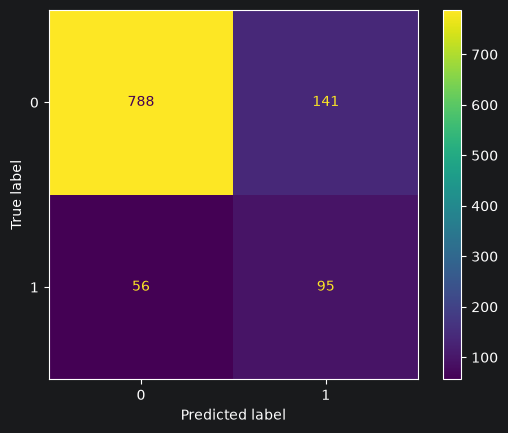

In [44]:
train_and_evaluate(classifier=RandomForestClassifier, best_params=rf0_best_params, X_train=X_train0, Y_train=Y_train, X_test=X_test0, Y_test=Y_test)

### PCA with 50 components

In [28]:
rf50_best_params = grid_search(estimator=RandomForestClassifier(), param_grid=rf_params, cv=5, scoring='f1', X=X_train50, Y=Y_train, randomized=True)

Best params: {'bootstrap': True, 'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 40, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 31, 'n_estimators': 1000}
F1 score: 0.48263406723115204


,mean_test_score,params
23,0.482634,"{'bootstrap': True, 'class_weight': 'balanced'..."
15,0.478801,"{'bootstrap': True, 'class_weight': 'balanced'..."
4,0.478061,"{'bootstrap': False, 'class_weight': 'balanced..."
32,0.475034,"{'bootstrap': True, 'class_weight': 'balanced'..."
1,0.474601,"{'bootstrap': True, 'class_weight': 'balanced'..."


Accuracy: 0.8212962962962963
F1 score: 0.48257372654155495
Precision: 0.40540540540540543
Recall: 0.5960264900662252


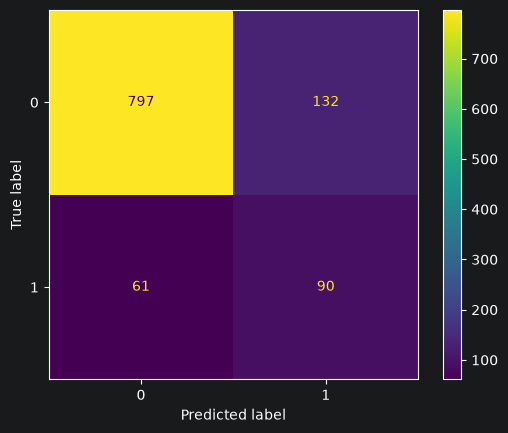

In [29]:
train_and_evaluate(classifier=RandomForestClassifier, best_params=rf50_best_params, X_train=X_train50, Y_train=Y_train, X_test=X_test50, Y_test=Y_test)

# XGBoost

In [56]:
from sklearn.model_selection import train_test_split

class EarlyStoppingXGBClassifier(xgb.XGBClassifier):
    def fit(self, X, y, **kwargs):
        X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)
        return super().fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

In [57]:
from scipy.stats import randint, uniform, loguniform

scale_pos_weight_ratio = (Y_train == 0).sum() / (Y_train == 1).sum()

xgb_params = {
    "n_estimators": [1000],                                  # fiksno, early stopping bira stvaran broj
    "early_stopping_rounds": randint(10, 50),
    "max_depth": randint(3, 10),
    "learning_rate": loguniform(0.01, 0.3),
    "min_child_weight": randint(1, 10),
    "subsample": uniform(0.6, 0.4),                           # opseg [0.6, 1.0]
    "colsample_bytree": uniform(0.6, 0.4),                    # opseg [0.6, 1.0]
    "gamma": uniform(0, 5),
    "reg_alpha": loguniform(1e-3, 10),
    "reg_lambda": loguniform(1e-3, 10),
    "scale_pos_weight": uniform(scale_pos_weight_ratio * 0.5, scale_pos_weight_ratio * 1.0),  # opseg [0.5x, 1.5x]
}

### PCA with 95% explained variance

In [58]:
xgb95_best_params = grid_search(estimator=EarlyStoppingXGBClassifier(), param_grid=xgb_params, cv=5, scoring='f1', X=X_train95, Y=Y_train, randomized=True)

Best params: {'colsample_bytree': np.float64(0.9784778171526761), 'early_stopping_rounds': 25, 'gamma': np.float64(3.9480907139727694), 'learning_rate': np.float64(0.013637114073970707), 'max_depth': 4, 'min_child_weight': 7, 'n_estimators': 1000, 'reg_alpha': np.float64(9.632188390621609), 'reg_lambda': np.float64(0.001672956384704076), 'scale_pos_weight': np.float64(7.6190144520537135), 'subsample': np.float64(0.8183663080659955)}
F1 score: 0.48329151801199377


,mean_test_score,params
45,0.483292,"{'colsample_bytree': 0.9784778171526761, 'earl..."
72,0.474556,"{'colsample_bytree': 0.9223459546964574, 'earl..."
16,0.470651,"{'colsample_bytree': 0.8123738333268545, 'earl..."
11,0.468207,"{'colsample_bytree': 0.9630265895704372, 'earl..."
78,0.467955,"{'colsample_bytree': 0.6265985069467109, 'earl..."


Accuracy: 0.8018518518518518
F1 score: 0.46766169154228854
Precision: 0.3745019920318725
Recall: 0.6225165562913907


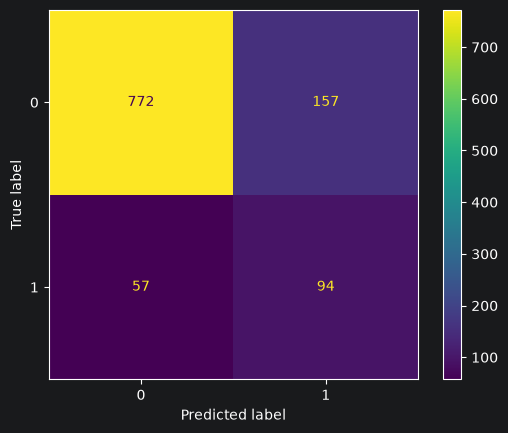

In [59]:
train_and_evaluate(classifier=EarlyStoppingXGBClassifier, best_params=xgb95_best_params, X_train=X_train95, Y_train=Y_train, X_test=X_test95, Y_test=Y_test)

In [60]:
xgb0_best_params = grid_search(estimator=EarlyStoppingXGBClassifier(), param_grid=xgb_params, cv=5, scoring='f1', X=X_train0, Y=Y_train, randomized=True)

Best params: {'colsample_bytree': np.float64(0.9223459546964574), 'early_stopping_rounds': 33, 'gamma': np.float64(4.483827123132126), 'learning_rate': np.float64(0.013137567821944727), 'max_depth': 5, 'min_child_weight': 8, 'n_estimators': 1000, 'reg_alpha': np.float64(0.6135441922383201), 'reg_lambda': np.float64(9.750393411292787), 'scale_pos_weight': np.float64(8.601849574226355), 'subsample': np.float64(0.830399367122264)}
F1 score: 0.5009433648388314


,mean_test_score,params
72,0.500943,"{'colsample_bytree': 0.9223459546964574, 'earl..."
45,0.498724,"{'colsample_bytree': 0.9784778171526761, 'earl..."
55,0.497611,"{'colsample_bytree': 0.9464255558001633, 'earl..."
79,0.496491,"{'colsample_bytree': 0.6745619947152576, 'earl..."
16,0.493618,"{'colsample_bytree': 0.8123738333268545, 'earl..."


Accuracy: 0.8351851851851851
F1 score: 0.5136612021857924
Precision: 0.4372093023255814
Recall: 0.6225165562913907


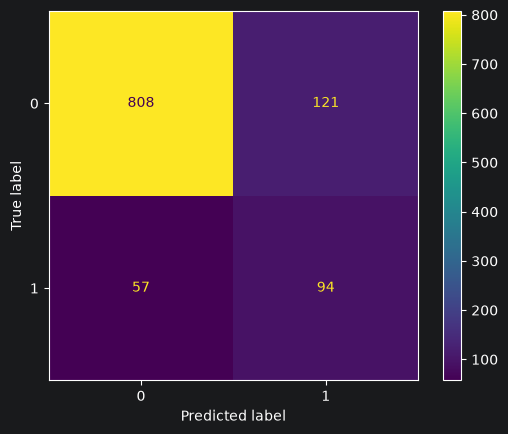

In [61]:
train_and_evaluate(classifier=EarlyStoppingXGBClassifier, best_params=xgb0_best_params, X_train=X_train0, Y_train=Y_train, X_test=X_test0, Y_test=Y_test)

### PCA with 50 components

In [62]:
xgb50_best_params = grid_search(estimator=EarlyStoppingXGBClassifier(), param_grid=xgb_params, cv=5, scoring='f1', X=X_train50, Y=Y_train, randomized=True)

Best params: {'colsample_bytree': np.float64(0.9223459546964574), 'early_stopping_rounds': 33, 'gamma': np.float64(4.483827123132126), 'learning_rate': np.float64(0.013137567821944727), 'max_depth': 5, 'min_child_weight': 8, 'n_estimators': 1000, 'reg_alpha': np.float64(0.6135441922383201), 'reg_lambda': np.float64(9.750393411292787), 'scale_pos_weight': np.float64(8.601849574226355), 'subsample': np.float64(0.830399367122264)}
F1 score: 0.485792022725985


,mean_test_score,params
72,0.485792,"{'colsample_bytree': 0.9223459546964574, 'earl..."
24,0.482692,"{'colsample_bytree': 0.7001847274422337, 'earl..."
45,0.478994,"{'colsample_bytree': 0.9784778171526761, 'earl..."
79,0.478466,"{'colsample_bytree': 0.6745619947152576, 'earl..."
91,0.475111,"{'colsample_bytree': 0.806069472962725, 'early..."


Accuracy: 0.825
F1 score: 0.4932975871313673
Precision: 0.4144144144144144
Recall: 0.609271523178808


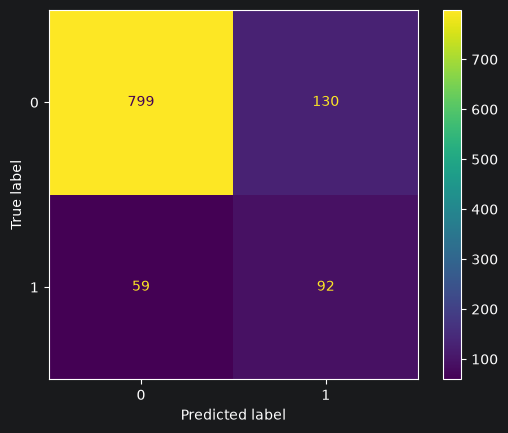

In [63]:
train_and_evaluate(classifier=EarlyStoppingXGBClassifier, best_params=xgb50_best_params, X_train=X_train50, Y_train=Y_train, X_test=X_test50, Y_test=Y_test)

# MLP (Multilayer Perceptron)

In [115]:
mlp_params = {
    "hidden_layer_sizes": [(16,), (32,), (64,), (128,), (32,16), (64,32), (128,64), (64,32,16), (128,64,32), (256, 128, 64), (512, 256, 128, 64), (256, 128, 64, 32), (128, 64, 32, 16)],
    "activation": ["relu", "tanh", "logistic"],
    "solver": ["adam"],
    "learning_rate_init": [0.001, 0.005, 0.01, 0.05, 0.1],
    "alpha": [0.000001, 0.00001, 0.0001, 0.001, 0.01],
    "batch_size": [32, 64, 128, 256, 512, 1024],
    "learning_rate": ["adaptive"],
    "max_iter": [2000],
    "early_stopping": [True],
    "validation_fraction": [0.2],
    "n_iter_no_change": [5, 10, 20]
}

### PCA with 95% explained variance

In [116]:
mlp95_best_params = grid_search(estimator=MLPClassifier(), param_grid=mlp_params, cv=5, scoring='f1', X=X_train95, Y=Y_train, randomized=True)

Best params: {'validation_fraction': 0.2, 'solver': 'adam', 'n_iter_no_change': 5, 'max_iter': 2000, 'learning_rate_init': 0.001, 'learning_rate': 'adaptive', 'hidden_layer_sizes': (128,), 'early_stopping': True, 'batch_size': 128, 'alpha': 0.01, 'activation': 'tanh'}
F1 score: 0.4248516523882694


,mean_test_score,params
90,0.424852,"{'validation_fraction': 0.2, 'solver': 'adam',..."
58,0.416599,"{'validation_fraction': 0.2, 'solver': 'adam',..."
59,0.406844,"{'validation_fraction': 0.2, 'solver': 'adam',..."
71,0.406235,"{'validation_fraction': 0.2, 'solver': 'adam',..."
31,0.402729,"{'validation_fraction': 0.2, 'solver': 'adam',..."


Accuracy: 0.8601851851851852
F1 score: 0.4664310954063604
Precision: 0.5
Recall: 0.4370860927152318


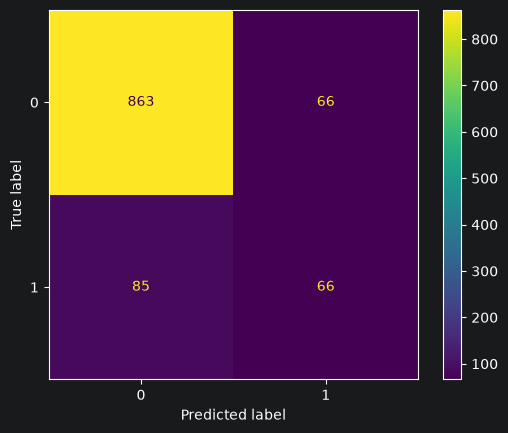

In [117]:
train_and_evaluate(classifier=MLPClassifier, best_params=mlp95_best_params, X_train=X_train95, Y_train=Y_train, X_test=X_test95, Y_test=Y_test)

### Without PCA

In [118]:
mlp0_best_params = grid_search(estimator=MLPClassifier(), param_grid=mlp_params, cv=5, scoring='f1', X=X_train0, Y=Y_train, randomized=True)

Best params: {'validation_fraction': 0.2, 'solver': 'adam', 'n_iter_no_change': 5, 'max_iter': 2000, 'learning_rate_init': 0.01, 'learning_rate': 'adaptive', 'hidden_layer_sizes': (128, 64), 'early_stopping': True, 'batch_size': 128, 'alpha': 0.01, 'activation': 'tanh'}
F1 score: 0.41583865683174626


,mean_test_score,params
36,0.415839,"{'validation_fraction': 0.2, 'solver': 'adam',..."
9,0.407076,"{'validation_fraction': 0.2, 'solver': 'adam',..."
31,0.406826,"{'validation_fraction': 0.2, 'solver': 'adam',..."
48,0.401784,"{'validation_fraction': 0.2, 'solver': 'adam',..."
53,0.396099,"{'validation_fraction': 0.2, 'solver': 'adam',..."


Accuracy: 0.8731481481481481
F1 score: 0.4868913857677903
Precision: 0.5603448275862069
Recall: 0.4304635761589404


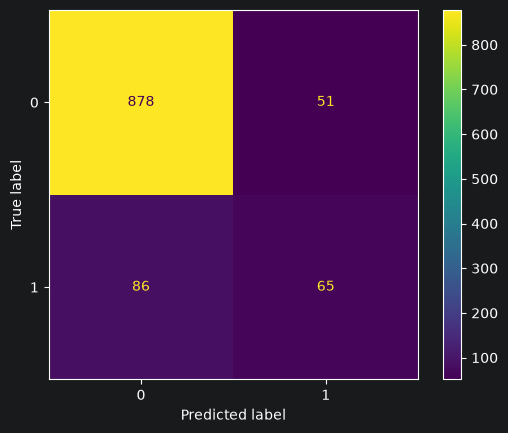

In [119]:
train_and_evaluate(classifier=MLPClassifier, best_params=mlp0_best_params, X_train=X_train0, Y_train=Y_train, X_test=X_test0, Y_test=Y_test)

### PCA with 50 components

In [120]:
mlp50_best_params = grid_search(estimator=MLPClassifier(), param_grid=mlp_params, cv=5, scoring='f1', X=X_train50, Y=Y_train, randomized=True)

Best params: {'validation_fraction': 0.2, 'solver': 'adam', 'n_iter_no_change': 5, 'max_iter': 2000, 'learning_rate_init': 0.005, 'learning_rate': 'adaptive', 'hidden_layer_sizes': (128,), 'early_stopping': True, 'batch_size': 64, 'alpha': 0.0001, 'activation': 'tanh'}
F1 score: 0.4059946755882219


,mean_test_score,params
34,0.405995,"{'validation_fraction': 0.2, 'solver': 'adam',..."
26,0.397685,"{'validation_fraction': 0.2, 'solver': 'adam',..."
41,0.395296,"{'validation_fraction': 0.2, 'solver': 'adam',..."
31,0.383609,"{'validation_fraction': 0.2, 'solver': 'adam',..."
28,0.377479,"{'validation_fraction': 0.2, 'solver': 'adam',..."


Accuracy: 0.8629629629629629
F1 score: 0.3884297520661157
Precision: 0.5164835164835165
Recall: 0.31125827814569534


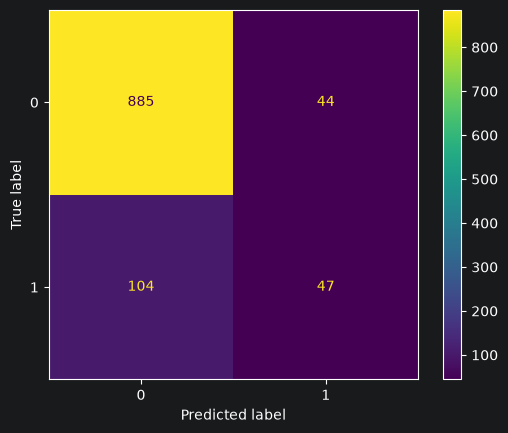

In [121]:
train_and_evaluate(classifier=MLPClassifier, best_params=mlp50_best_params, X_train=X_train50, Y_train=Y_train, X_test=X_test50, Y_test=Y_test)